# Multi-Query Attention — Math

## Standard Multi-Head Attention (MHA) recap

Given input sequences $Q \in \mathbb{R}^{b \times s_l \times d}$, $K, V \in \mathbb{R}^{b \times s_k \times d}$, MHA projects each into $H$ separate heads:

$$Q_h = Q W_h^Q, \quad K_h = K W_h^K, \quad V_h = V W_h^V$$

where $W_h^Q, W_h^K, W_h^V \in \mathbb{R}^{d \times d_{head}}$ for each head $h = 1 \ldots H$.

Each head independently computes:

$$\text{head}_h = \text{softmax}\!\left(\frac{Q_h K_h^\top}{\sqrt{d_{head}}}\right) V_h$$

Memory cost: $H$ separate K/V projections cached during inference.

---

## Multi-Query Attention (MQA) — Shazeer 2019

**Key idea:** Q keeps $H$ heads, but K and V are projected to a **single shared head**:

$$Q_h = Q W_h^Q \in \mathbb{R}^{b \times s_l \times d_{head}}, \quad h = 1 \ldots H$$

$$K = K W^K \in \mathbb{R}^{b \times s_k \times d_{head}} \quad \text{(one shared projection)}$$

$$V = V W^V \in \mathbb{R}^{b \times s_k \times d_{head}} \quad \text{(one shared projection)}$$

The attention for head $h$ is:

$$\text{score}_h = \frac{Q_h \, K^\top}{\sqrt{d_{head}}} \in \mathbb{R}^{b \times s_l \times s_k}$$

Optionally apply a mask $M$ (0 = blocked, 1 = allowed):

$$\text{score}_h = \text{score}_h \;\text{where } M=1, \quad -\infty \;\text{where } M=0$$

$$\alpha_h = \text{softmax}(\text{score}_h) \in \mathbb{R}^{b \times s_l \times s_k}$$

$$\text{head}_h = \alpha_h \, V \in \mathbb{R}^{b \times s_l \times d_{head}}$$

Concatenate all heads and project back:

$$\text{MQA}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H) \in \mathbb{R}^{b \times s_l \times d}$$

where $d = H \times d_{head}$.

---

## Why MQA?

| | MHA | MQA |
|---|---|---|
| Q projections | $H$ | $H$ |
| K projections | $H$ | **1** |
| V projections | $H$ | **1** |
| KV-cache memory | $O(H \cdot s_k \cdot d_{head})$ | $O(s_k \cdot d_{head})$ |
| Expressiveness | Higher | Slightly lower |

MQA reduces the KV-cache size by a factor of $H$, which is critical for fast autoregressive decoding in large language models.

# Multi-Query Attention — Step-by-Step Visualization

Multi-Query Attention (MQA) differs from standard Multi-Head Attention:
- **Q** is projected into multiple heads: shape `(b, head_num, sl, head_dim)`
- **K** and **V** are projected into a **single shared head**: shape `(b, 1, sk, head_dim)`
- Every Q head attends to the same K/V — reduces memory during inference

In [9]:
from typing import Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

torch.manual_seed(42)

## 1. Model Definition

In [10]:
class MultiQueryAttention(nn.Module):
    def __init__(self, hidden_dim: int, head_dim: int):
        super().__init__()

        self.head_dim = head_dim
        self.hidden_dim = hidden_dim

        if self.hidden_dim % self.head_dim != 0:
            raise ValueError(
                f"hidden_dim ({hidden_dim}) must be divisible by head_dim ({head_dim})"
            )

        self.head_num = self.hidden_dim // self.head_dim

        # Q: multi-head projection  → output hidden_dim = head_num * head_dim
        self.map_q = nn.Linear(self.hidden_dim, self.hidden_dim)
        # K, V: single shared head → output head_dim
        self.map_k = nn.Linear(self.hidden_dim, self.head_dim)
        self.map_v = nn.Linear(self.hidden_dim, self.head_dim)

    def forward(
        self,
        q: torch.Tensor,            # (b, sl, hidden_dim)
        k: torch.Tensor,            # (b, sk, hidden_dim)
        v: torch.Tensor,            # (b, sk, hidden_dim)
        mask: Optional[torch.Tensor] = None,  # (1, 1, sl, sk) broadcastable
        return_weights: bool = False,
    ):
        b, sl, _ = q.shape
        _, sk, _ = k.shape

        # --- Linear projections ---
        q = self.map_q(q)  # (b, sl, hidden_dim)
        k = self.map_k(k)  # (b, sk, head_dim)
        v = self.map_v(v)  # (b, sk, head_dim)

        # --- Reshape Q into multiple heads; K/V stay as single head ---
        q = q.view(b, sl, self.head_num, self.head_dim).transpose(1, 2)
        # q: (b, head_num, sl, head_dim)
        k = k.unsqueeze(1)  # (b, 1, sk, head_dim)  — shared across heads
        v = v.unsqueeze(1)  # (b, 1, sk, head_dim)  — shared across heads

        # --- Scaled dot-product scores ---
        scale = self.head_dim ** 0.5
        score = torch.matmul(q, k.transpose(-2, -1)) / scale
        # score: (b, head_num, sl, sk)

        # --- Apply mask (0 = ignore position) ---
        if mask is not None:
            score = score.masked_fill(mask == 0, float("-inf"))

        # --- Softmax over key dimension ---
        attention_weight = torch.softmax(score, dim=-1)
        # attention_weight: (b, head_num, sl, sk)

        # --- Weighted sum of values ---
        output = torch.matmul(attention_weight, v)
        # output: (b, head_num, sl, head_dim)

        # --- Merge heads ---
        output = output.transpose(1, 2).contiguous().view(b, sl, self.hidden_dim)
        # output: (b, sl, hidden_dim)

        if return_weights:
            return output, attention_weight
        return output

## 2. Instantiate the model and check shapes

In [11]:
HIDDEN_DIM = 8
HEAD_DIM   = 2
BATCH      = 1
SL         = 5   # query sequence length
SK         = 4   # key/value sequence length

model = MultiQueryAttention(hidden_dim=HIDDEN_DIM, head_dim=HEAD_DIM)
print(model)
print(f"\nhead_num = {model.head_num}  (hidden_dim {HIDDEN_DIM} / head_dim {HEAD_DIM})")

MultiQueryAttention(
  (map_q): Linear(in_features=8, out_features=8, bias=True)
  (map_k): Linear(in_features=8, out_features=2, bias=True)
  (map_v): Linear(in_features=8, out_features=2, bias=True)
)

head_num = 4  (hidden_dim 8 / head_dim 2)


## 3. Run WITHOUT a mask — attends to every position

Output shape: torch.Size([1, 5, 8])
Attention weights shape: torch.Size([1, 4, 5, 4])


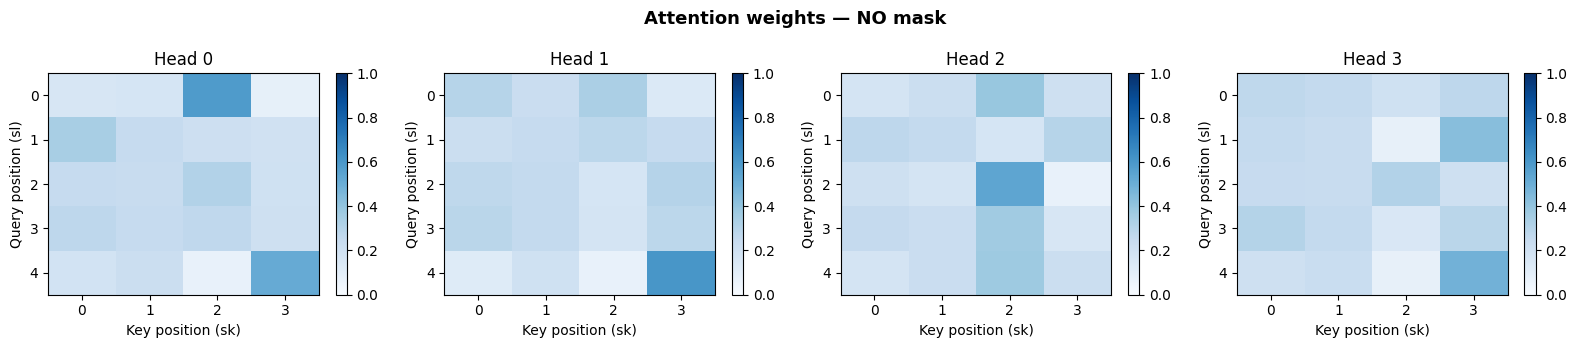

In [12]:
torch.manual_seed(0)
q = torch.randn(BATCH, SL, HIDDEN_DIM)
k = torch.randn(BATCH, SK, HIDDEN_DIM)
v = torch.randn(BATCH, SK, HIDDEN_DIM)

with torch.no_grad():
    out_no_mask, weights_no_mask = model(q, k, v, mask=None, return_weights=True)

print("Output shape:", out_no_mask.shape)          # (1, 5, 8)
print("Attention weights shape:", weights_no_mask.shape)  # (1, head_num, 5, 4)


def plot_weights(weights, title, ax_titles=None):
    """weights: (head_num, sl, sk)"""
    head_num, sl, sk = weights.shape
    fig, axes = plt.subplots(1, head_num, figsize=(4 * head_num, 3.5))
    if head_num == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for h, ax in enumerate(axes):
        im = ax.imshow(weights[h].numpy(), vmin=0, vmax=1, cmap="Blues", aspect="auto")
        ax.set_title(ax_titles[h] if ax_titles else f"Head {h}")
        ax.set_xlabel("Key position (sk)")
        ax.set_ylabel("Query position (sl)")
        ax.set_xticks(range(sk))
        ax.set_yticks(range(sl))
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


# weights_no_mask[0]: (head_num, sl, sk)
plot_weights(
    weights_no_mask[0].detach(),
    title="Attention weights — NO mask",
    ax_titles=[f"Head {h}" for h in range(model.head_num)],
)

## 4. Run WITH a causal mask — each query can only attend to earlier keys

A causal (lower-triangular) mask blocks future positions.  
Here `sl=5`, `sk=4`, so position 0 attends only to key 0, position 1 to keys 0-1, etc.

Causal mask (sl x sk):
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


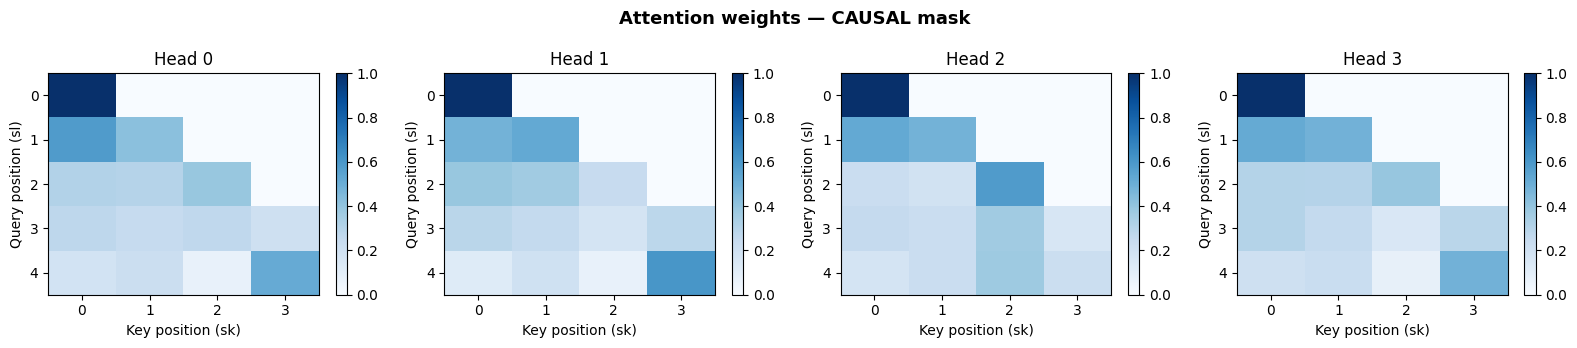

In [13]:
# Build a causal mask: 1 = allowed, 0 = blocked
# Shape must broadcast to (b, head_num, sl, sk)
causal_mask = torch.ones(1, 1, SL, SK).tril()  # lower triangular
print("Causal mask (sl x sk):")
print(causal_mask[0, 0])

with torch.no_grad():
    out_causal, weights_causal = model(q, k, v, mask=causal_mask, return_weights=True)

plot_weights(
    weights_causal[0].detach(),
    title="Attention weights — CAUSAL mask",
    ax_titles=[f"Head {h}" for h in range(model.head_num)],
)

## 5. Run WITH a padding mask — some key positions are padding and ignored

Padding mask (sl x sk):
tensor([[1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.]])


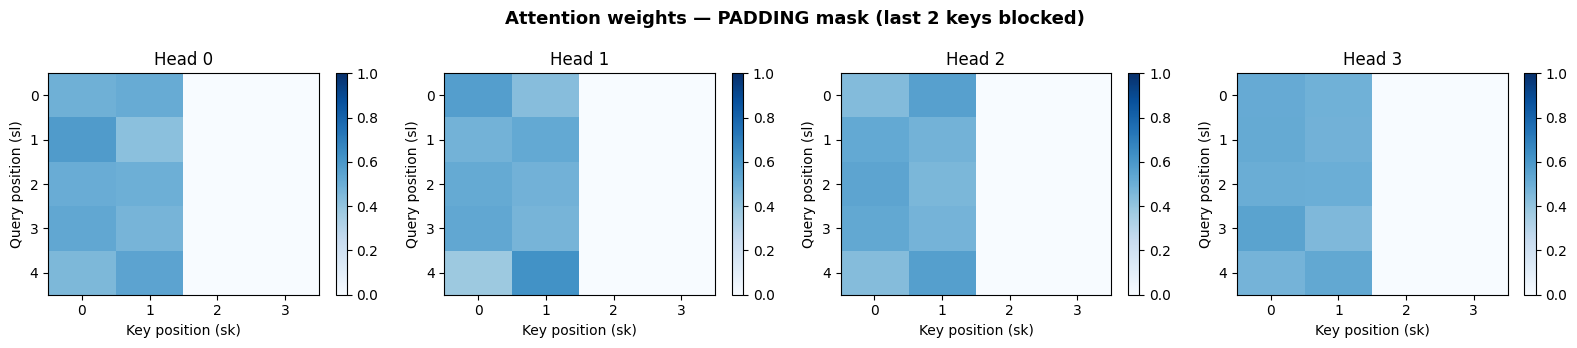

In [14]:
# Pretend the last 2 key positions are padding (set to 0)
padding_mask = torch.ones(1, 1, SL, SK)
padding_mask[:, :, :, -2:] = 0   # block last 2 key positions
print("Padding mask (sl x sk):")
print(padding_mask[0, 0])

with torch.no_grad():
    out_pad, weights_pad = model(q, k, v, mask=padding_mask, return_weights=True)

plot_weights(
    weights_pad[0].detach(),
    title="Attention weights — PADDING mask (last 2 keys blocked)",
    ax_titles=[f"Head {h}" for h in range(model.head_num)],
)

## 6. Multi-Query vs Multi-Head — key difference visualized

In MQA all heads share the **same** K/V projection, so K/V attention patterns are identical across heads after softmax weighting. Only Q differs per head.

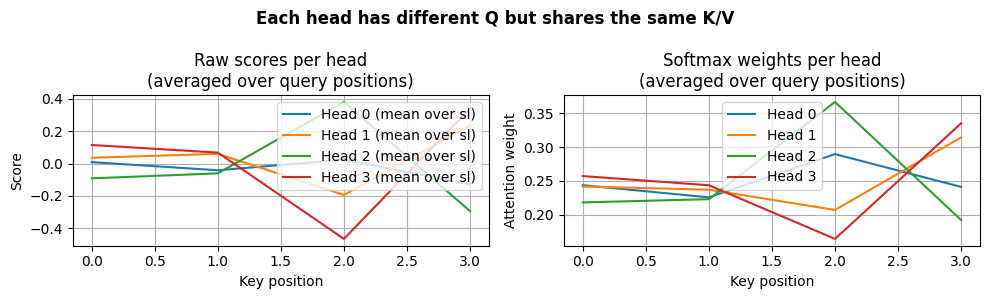

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Left: scores before softmax per head (no mask)
with torch.no_grad():
    q_proj = model.map_q(q)  # (1, sl, hidden_dim)
    k_proj = model.map_k(k)  # (1, sk, head_dim)
    q_h = q_proj.view(BATCH, SL, model.head_num, HEAD_DIM).transpose(1, 2)  # (1, hn, sl, hd)
    k_h = k_proj.unsqueeze(1)  # (1, 1, sk, hd)
    scores = torch.matmul(q_h, k_h.transpose(-2, -1)) / (HEAD_DIM ** 0.5)  # (1, hn, sl, sk)

for h in range(model.head_num):
    s = scores[0, h].detach().numpy()
    axes[0].plot(s.mean(axis=0), label=f"Head {h} (mean over sl)")
axes[0].set_title("Raw scores per head\n(averaged over query positions)")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True)

# Right: softmax weights per head
for h in range(model.head_num):
    w = weights_no_mask[0, h].detach().numpy()
    axes[1].plot(w.mean(axis=0), label=f"Head {h}")
axes[1].set_title("Softmax weights per head\n(averaged over query positions)")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Attention weight")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Each head has different Q but shares the same K/V", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Summary of tensor shapes at each step

In [16]:
print(f"Config: batch={BATCH}, sl={SL}, sk={SK}, hidden_dim={HIDDEN_DIM}, head_dim={HEAD_DIM}, head_num={model.head_num}")
print()
print(f"Input  q:             {tuple(torch.randn(BATCH, SL, HIDDEN_DIM).shape)}")
print(f"Input  k, v:          {tuple(torch.randn(BATCH, SK, HIDDEN_DIM).shape)}")
print()
print(f"After map_q(q):       (b, sl, hidden_dim) = ({BATCH}, {SL}, {HIDDEN_DIM})")
print(f"After map_k(k):       (b, sk, head_dim)   = ({BATCH}, {SK}, {HEAD_DIM})")
print(f"After map_v(v):       (b, sk, head_dim)   = ({BATCH}, {SK}, {HEAD_DIM})")
print()
print(f"Reshape q:            (b, head_num, sl, head_dim) = ({BATCH}, {model.head_num}, {SL}, {HEAD_DIM})")
print(f"Unsqueeze k:          (b, 1, sk, head_dim)        = ({BATCH}, 1, {SK}, {HEAD_DIM})  ← shared")
print(f"Unsqueeze v:          (b, 1, sk, head_dim)        = ({BATCH}, 1, {SK}, {HEAD_DIM})  ← shared")
print()
print(f"Scores:               (b, head_num, sl, sk) = ({BATCH}, {model.head_num}, {SL}, {SK})")
print(f"Attention weights:    (b, head_num, sl, sk) = ({BATCH}, {model.head_num}, {SL}, {SK})")
print(f"Output (pre-merge):   (b, head_num, sl, head_dim) = ({BATCH}, {model.head_num}, {SL}, {HEAD_DIM})")
print(f"Output (final):       (b, sl, hidden_dim) = ({BATCH}, {SL}, {HIDDEN_DIM})")

Config: batch=1, sl=5, sk=4, hidden_dim=8, head_dim=2, head_num=4

Input  q:             (1, 5, 8)
Input  k, v:          (1, 4, 8)

After map_q(q):       (b, sl, hidden_dim) = (1, 5, 8)
After map_k(k):       (b, sk, head_dim)   = (1, 4, 2)
After map_v(v):       (b, sk, head_dim)   = (1, 4, 2)

Reshape q:            (b, head_num, sl, head_dim) = (1, 4, 5, 2)
Unsqueeze k:          (b, 1, sk, head_dim)        = (1, 1, 4, 2)  ← shared
Unsqueeze v:          (b, 1, sk, head_dim)        = (1, 1, 4, 2)  ← shared

Scores:               (b, head_num, sl, sk) = (1, 4, 5, 4)
Attention weights:    (b, head_num, sl, sk) = (1, 4, 5, 4)
Output (pre-merge):   (b, head_num, sl, head_dim) = (1, 4, 5, 2)
Output (final):       (b, sl, hidden_dim) = (1, 5, 8)
